# Разметка при помощи нейросети (CLIP, BERT)

Наши задачи:

* загружаем тексты и картинки
* прогоняем картинки через CLIP
* прогоняем картинки через BERT
* всё в один датасет
* сравниваем, рисуем графики

In [19]:
import pandas as pd
import torch
from PIL import Image
import os


In [5]:
import open_clip

# 1. Загружаем модель и "препроцессор" (он готовит картинку для нейросети)
# Мы возьмем модель ViT-B-32, она достаточно легкая и быстрая
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
tokenizer = open_clip.get_tokenizer('ViT-B-32')



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [6]:
df = pd.read_csv('news values data - rus (2).csv', encoding='utf-8')


In [11]:
labels = [
    "Aesthetic: beautiful, attractive",
    "Negativity: negative, as a disaster, conflict, controversy, criminal act",
    "Positivity: positive, for example, as a scientific breakthrough or heroic act",
    "Eliteness: of high status or fame (including but not limited to the people, countries, or institutions involved)",
    "Superlativeness: high intensity or large scope/scale",
    "Personalization: having a personal or ‘human’ face (involving non-elite actors, including eyewitnesses)",
    "Timeliness: timely in relation to the publication date: as new, recent, ongoing, about to happen, or otherwise relevant to the immediate situation/time (current or seasonal)",
    "Proximity: geographically or culturally near (in relation to the publication location/target audience)",
    "Unexpectedness: unexpected, for example, as unusual, strange, rare",
    "Impact: significant effects or consequences (not necessarily limited to impact on the target audience)",
    "Consonance: (stereo)typical (limited here to news actors, social groups, organizations, or countries/nations)"
]

value_names = [label.split(":")[0] for label in labels]

results = []

for i in range(1, 101):
    image_path = f"картинка {i}.png"

    if not os.path.exists(image_path):
        print(f"Файл {image_path} не найден, пропускаем")
        results.append({'image_name': f"картинка {i}.png", 'values': []})
        continue

    image = preprocess(Image.open(image_path)).unsqueeze(0)
    text = tokenizer(labels)

    with torch.no_grad(), torch.cuda.amp.autocast():
        image_features = model.encode_image(image)
        text_features = model.encode_text(text)

        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)

        logit_scale = model.logit_scale.exp()
        logits_per_image = logit_scale * image_features @ text_features.T
        probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]

    selected_values = [value_names[j] for j, p in enumerate(probs) if p > 0.1]

    results.append({
        'image_name': f"картинка {i}",
        'values': selected_values
    })

    print(f"{f'картинка {i}':<15} -> {', '.join(selected_values) if selected_values else 'нет ценностей >10%'}")

df_results = pd.DataFrame(results)

df_results.to_csv('clip_image_values1.csv', index=False, encoding='utf-8')


/tmp/ipykernel_1831/1920951210.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():


картинка 1      -> Negativity, Unexpectedness, Impact, Consonance
картинка 2      -> Consonance
картинка 3      -> Proximity, Unexpectedness
картинка 4      -> Positivity, Personalization, Unexpectedness
картинка 5      -> Aesthetic, Positivity, Superlativeness, Unexpectedness, Impact
картинка 6      -> Eliteness, Proximity, Unexpectedness, Consonance
картинка 7      -> Consonance
картинка 8      -> Positivity, Personalization, Unexpectedness
картинка 9      -> Positivity, Unexpectedness
картинка 10     -> Impact
картинка 11     -> Timeliness, Unexpectedness, Consonance
картинка 12     -> Aesthetic, Personalization, Consonance
картинка 13     -> Negativity, Consonance
картинка 14     -> Aesthetic, Unexpectedness
картинка 15     -> Unexpectedness
картинка 16     -> Eliteness, Personalization, Consonance
картинка 17     -> Positivity, Timeliness, Consonance
картинка 18     -> Aesthetic, Unexpectedness
картинка 19     -> Positivity, Unexpectedness
картинка 20     -> Impact, Consonance
кар

In [16]:
def format_clip_values(values_list):
    mapping = {
        'Aesthetic': 'AA',
        'Negativity': 'Neg',
        'Positivity': 'Pos',
        'Eliteness': 'Elite',
        'Superlativeness': 'Super',
        'Personalization': 'Pers',
        'Timeliness': 'Time',
        'Proximity': 'Prox',
        'Unexpectedness': 'Unexp',
        'Impact': 'Imp',
        'Consonance': 'Cons'
    }
    # Сокращаем названия и объединяем через \n
    short_values = [mapping[v] for v in values_list if v in mapping]
    return '\n'.join(short_values)

df_withAI = pd.DataFrame()

df_withAI['Номер новости'] = range(1, len(df) + 1)

df_withAI['Текст_руками'] = df['values_text']

df_withAI['Текст_BERT'] = None

df_withAI['Изображение_руками'] = df['values_image']

df_withAI['Изображение_CLIP'] = df_results['values'].apply(format_clip_values)

df_withAI['Отношение'] = df['relation']

df_withAI['Тип новости'] = df['news_type']

df_withAI.head()

,Номер новости,Текст_руками,Текст_BERT,Изображение_руками,Изображение_CLIP,Отношение,Тип новости
0,1,Elite\nImp\nNeg\nProx\nTime,None,Imp\nNeg,Neg\nUnexp\nImp\nCons,Extension,будущее экологии
1,2,Elite\nImp\nPos\nSuper\nTime,None,AA\nPos,Cons,Extension,недавнее событие
2,3,Imp\nNeg\nElite\n,None,AA\nSuper,Prox\nUnexp,Contradiction,недавнее событие
3,4,Elite\nImp\nNeg\nSuper\nTime,None,Neg\nPers\n,Pos\nPers\nUnexp,Extension,будущее экологии
4,5,Elite\nImp\nPos\nUnexp\n,None,Super\nUnexp,AA\nPos\nSuper\nUnexp\nImp,Modification,будущее экологии


# Теперь BERT

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation
from collections import Counter
import re

In [21]:
labels = [
    "Negativity: negative, as a disaster, conflict, controversy, criminal act",
    "Positivity: positive, as a scientific breakthrough or heroic act",
    "Eliteness: of high status or fame (including but not limited to the people, countries, or institutions involved)",
    "Superlativeness: high intensity or large scope/scale",
    "Personalization: having a personal or ‘human’ face (involving non-elite actors, including eyewitnesses)",
    "Timeliness: timely in relation to the publication date: as new, recent, ongoing, about to happen, or otherwise relevant to the immediate situation/time (current or seasonal)",
    "Proximity: geographically or culturally near (in relation to the publication location/target audience)",
    "Unexpectedness: unexpected, for example, as unusual, strange, rare",
    "Impact: significant effects or consequences (not necessarily limited to impact on the target audience)",
    "Consonance: (stereo)typical (limited here to news actors, social groups, organizations, or countries/nations)"
]

value_names = [label.split(":")[0] for label in labels]

# BERT

In [ ]:
!pip install datasets transformers scikit-learn

In [22]:
import re

# Функция для преобразования строки с тегами в множество
def parse_tags(cell):
    if pd.isna(cell):
        return set()
    # Разделяем по пробелам и переносам строк
    items = re.split(r'[ \n]+', str(cell))
    return {item.strip() for item in items if item.strip()}

# Создаём столбец text_tags_set из values_text
df['text_tags_set'] = df['values_text'].apply(parse_tags)

# Проверяем результат
print(df['text_tags_set'].head())

0     {Time, Imp, Neg, Elite, Prox}
1    {Pos, Time, Super, Imp, Elite}
2                 {Imp, Elite, Neg}
3    {Time, Super, Imp, Neg, Elite}
4          {Imp, Unexp, Elite, Pos}
Name: text_tags_set, dtype: object


In [35]:
import torch
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from torch.optim import AdamW
from sklearn.utils.class_weight import compute_class_weight

# --- 1. ТВОИ ДАННЫЕ ---
texts = df['message'].tolist()

# Список ценностей (короткие названия)
text_values_only = ['Neg', 'Imp', 'Elite', 'Time', 'Super', 'Prox', 'Pos', 'Pers', 'Cons', 'Unexp']

# Создаём бинарные метки
y = []
for idx, row in df.iterrows():
    tags = row['text_tags_set']
    labels = [1 if val in tags else 0 for val in text_values_only]
    y.append(labels)
y = np.array(y)

print(f"Загружено {len(texts)} текстов")
print(f"Размер меток: {y.shape}")

# --- 2. ЗАГРУЗКА МОДЕЛИ ---
MODEL_NAME = 'cointegrated/rubert-tiny2'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# --- 3. ФУНКЦИЯ ТОКЕНИЗАЦИИ ---
def tokenize_function(texts):
    return tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors='pt')

# --- 4. 5-FOLD КРОСС-ВАЛИДАЦИЯ ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold = 1
all_true = []
all_preds = []

for train_index, test_index in kf.split(texts):
    print(f"\n--- Fold {fold}/5 ---")

    X_train = [texts[i] for i in train_index]
    X_test = [texts[i] for i in test_index]
    y_train = y[train_index]
    y_test = y[test_index]

    # Вычисляем веса классов для балансировки
    class_weights = []
    for i in range(len(text_values_only)):
        weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train[:, i])
        class_weights.append(torch.tensor([weights[0], weights[1]], dtype=torch.float32))

    # Токенизируем
    train_enc = tokenize_function(X_train)
    test_enc = tokenize_function(X_test)

    # Датасеты
    train_dataset = TensorDataset(
        train_enc['input_ids'],
        train_enc['attention_mask'],
        torch.tensor(y_train, dtype=torch.float32)
    )
    test_dataset = TensorDataset(
        test_enc['input_ids'],
        test_enc['attention_mask'],
        torch.tensor(y_test, dtype=torch.float32)
    )

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)  # увеличил batch_size
    test_loader = DataLoader(test_dataset, batch_size=8)

    # Пересоздаём модель
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(text_values_only))
    optimizer = AdamW(model.parameters(), lr=3e-5)  # увеличил learning rate

    # Обучение
    model.train()
    for epoch in range(10):  # увеличил эпохи до 10
        loop = tqdm(train_loader, leave=False)
        for batch in loop:
            optimizer.zero_grad()
            input_ids, attention_mask, labels = batch

            outputs = model(input_ids, attention_mask=attention_mask)

            # Взвешенная бинарная кросс-энтропия для каждого класса
            loss = 0
            for i in range(len(text_values_only)):
                pos_weight = class_weights[i][1] / class_weights[i][0]
                bce_loss = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))
                loss += bce_loss(outputs.logits[:, i], labels[:, i])

            loss.backward()
            optimizer.step()
            loop.set_description(f'Epoch {epoch+1}')
            loop.set_postfix(loss=loss.item())

    # Тестирование с порогом 0.3
    model.eval()
    fold_preds = []
    fold_true = []
    with torch.no_grad():
        for batch in test_loader:
            input_ids, attention_mask, labels = batch
            outputs = model(input_ids, attention_mask=attention_mask)
            probs = torch.sigmoid(outputs.logits).cpu().numpy()
            preds = (probs > 0.3).astype(int)  # снизил порог до 0.3
            fold_preds.extend(preds)
            fold_true.extend(labels.numpy())

    all_preds.extend(fold_preds)
    all_true.extend(fold_true)
    fold += 1

# --- 5. РЕЗУЛЬТАТЫ ---
all_preds = np.array(all_preds)
all_true = np.array(all_true)

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ 5-FOLD КРОСС-ВАЛИДАЦИИ")
print("="*50)

for i, value in enumerate(text_values_only):
    acc = accuracy_score(all_true[:, i], all_preds[:, i])
    print(f"{value}: {acc:.2%}")

total_acc = accuracy_score(all_true.flatten(), all_preds.flatten())
print(f"\nОбщая точность (по всем ценностям): {total_acc:.2%}")

Загружено 100 текстов
Размер меток: (100, 10)

--- Fold 1/5 ---


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai


--- Fold 2/5 ---


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

...

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai


--- Fold 5/5 ---


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai


РЕЗУЛЬТАТЫ 5-FOLD КРОСС-ВАЛИДАЦИИ
Neg: 50.00%
Imp: 65.00%
Elite: 50.00%
Time: 56.00%
Super: 25.00%
Prox: 16.00%
Pos: 33.00%
Pers: 13.00%
Cons: 6.00%
Unexp: 18.00%

Общая точность (по всем ценностям): 33.20%


In [36]:
bert_predictions_full = []

for idx in range(len(df)):
    text = df.loc[idx, 'message']
    enc = tokenize_function([text])

    with torch.no_grad():
        input_ids = enc['input_ids']
        attention_mask = enc['attention_mask']
        outputs = model(input_ids, attention_mask=attention_mask)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()[0]
        preds = (probs > 0.5).astype(int)

    predicted_values = [text_values_only[i] for i, p in enumerate(preds) if p == 1]
    bert_predictions_full.append(predicted_values)

# Сравнение
for idx in range(4, 8):
    print(f"\nНовость {idx+1}:")
    print(f"  Ручная разметка: {df.loc[idx, 'text_tags_set']}")
    print(f"  BERT предсказал: {bert_predictions_full[idx]}")


Новость 5:
  Ручная разметка: {'Imp', 'Unexp', 'Elite', 'Pos'}
  BERT предсказал: ['Imp', 'Elite', 'Pos', 'Unexp']

Новость 6:
  Ручная разметка: {'Imp', 'Neg', 'Prox'}
  BERT предсказал: ['Neg', 'Imp', 'Super', 'Prox']

Новость 7:
  Ручная разметка: {'Neg', 'Unexp', 'Elite', 'Time'}
  BERT предсказал: ['Neg', 'Elite', 'Time', 'Pos', 'Cons', 'Unexp']

Новость 8:
  Ручная разметка: {'Imp', 'Elite'}
  BERT предсказал: ['Imp', 'Elite', 'Time', 'Pos']


In [37]:
bert_predictions_full = []

for idx in range(len(df)):
    text = df.loc[idx, 'message']
    enc = tokenize_function([text])

    with torch.no_grad():
        input_ids = enc['input_ids']
        attention_mask = enc['attention_mask']
        outputs = model(input_ids, attention_mask=attention_mask)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()[0]
        preds = (probs > 0.5).astype(int)

    predicted_values = [text_values_only[i] for i, p in enumerate(preds) if p == 1]
    bert_predictions_full.append(predicted_values)

df_withAI['Текст_BERT'] = bert_predictions_full

df_withAI.head()

,Номер новости,Текст_руками,Текст_BERT,Изображение_руками,Изображение_CLIP,Отношение,Тип новости
0,1,Elite\nImp\nNeg\nProx\nTime,"[Neg, Imp, Elite, Time, Super, Prox, Pers]",Imp\nNeg,Neg\nUnexp\nImp\nCons,Extension,будущее экологии
1,2,Elite\nImp\nPos\nSuper\nTime,"[Neg, Imp, Elite, Super, Pos]",AA\nPos,Cons,Extension,недавнее событие
2,3,Imp\nNeg\nElite\n,"[Neg, Imp, Time, Super]",AA\nSuper,Prox\nUnexp,Contradiction,недавнее событие
3,4,Elite\nImp\nNeg\nSuper\nTime,"[Neg, Imp, Super]",Neg\nPers\n,Pos\nPers\nUnexp,Extension,будущее экологии
4,5,Elite\nImp\nPos\nUnexp\n,"[Imp, Elite, Pos, Unexp]",Super\nUnexp,AA\nPos\nSuper\nUnexp\nImp,Modification,будущее экологии


In [38]:
bert_predictions_full = []

for idx in range(len(df)):
    text = df.loc[idx, 'message']
    enc = tokenize_function([text])

    with torch.no_grad():
        input_ids = enc['input_ids']
        attention_mask = enc['attention_mask']
        outputs = model(input_ids, attention_mask=attention_mask)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()[0]
        preds = (probs > 0.5).astype(int)

    predicted_values = [text_values_only[i] for i, p in enumerate(preds) if p == 1]
    bert_predictions_full.append('\n'.join(predicted_values))

df_withAI['Текст_BERT'] = bert_predictions_full

df_withAI.head()

,Номер новости,Текст_руками,Текст_BERT,Изображение_руками,Изображение_CLIP,Отношение,Тип новости
0,1,Elite\nImp\nNeg\nProx\nTime,Neg\nImp\nElite\nTime\nSuper\nProx\nPers,Imp\nNeg,Neg\nUnexp\nImp\nCons,Extension,будущее экологии
1,2,Elite\nImp\nPos\nSuper\nTime,Neg\nImp\nElite\nSuper\nPos,AA\nPos,Cons,Extension,недавнее событие
2,3,Imp\nNeg\nElite\n,Neg\nImp\nTime\nSuper,AA\nSuper,Prox\nUnexp,Contradiction,недавнее событие
3,4,Elite\nImp\nNeg\nSuper\nTime,Neg\nImp\nSuper,Neg\nPers\n,Pos\nPers\nUnexp,Extension,будущее экологии
4,5,Elite\nImp\nPos\nUnexp\n,Imp\nElite\nPos\nUnexp,Super\nUnexp,AA\nPos\nSuper\nUnexp\nImp,Modification,будущее экологии


In [31]:
df_withAI.to_csv('df_withAI.csv', index=False, encoding='utf-8')
from google.colab import files
files.download('df_withAI.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Статистика

In [39]:
# Функция для преобразования строки с \n в множество
def str_to_set(s):
    if pd.isna(s) or s == '':
        return set()
    return set(s.split('\n'))

# Считаем совпадения для CLIP
clip_matches = []
for idx in range(len(df_withAI)):
    human = str_to_set(df_withAI.loc[idx, 'Изображение_руками'])
    clip = str_to_set(df_withAI.loc[idx, 'Изображение_CLIP'])

    if len(human) > 0:
        match_percent = len(human & clip) / len(human) * 100
    else:
        match_percent = 100 if len(clip) == 0 else 0

    clip_matches.append(match_percent)

# Считаем совпадения для BERT
bert_matches = []
for idx in range(len(df_withAI)):
    human = str_to_set(df_withAI.loc[idx, 'Текст_руками'])
    bert = str_to_set(df_withAI.loc[idx, 'Текст_BERT'])

    if len(human) > 0:
        match_percent = len(human & bert) / len(human) * 100
    else:
        match_percent = 100 if len(bert) == 0 else 0

    bert_matches.append(match_percent)

# Выводим статистику
print(f"Средний процент совпадений CLIP с ручной разметкой: {np.mean(clip_matches):.1f}%")
print(f"Средний процент совпадений BERT с ручной разметкой: {np.mean(bert_matches):.1f}%")

Средний процент совпадений CLIP с ручной разметкой: 39.1%
Средний процент совпадений BERT с ручной разметкой: 84.6%


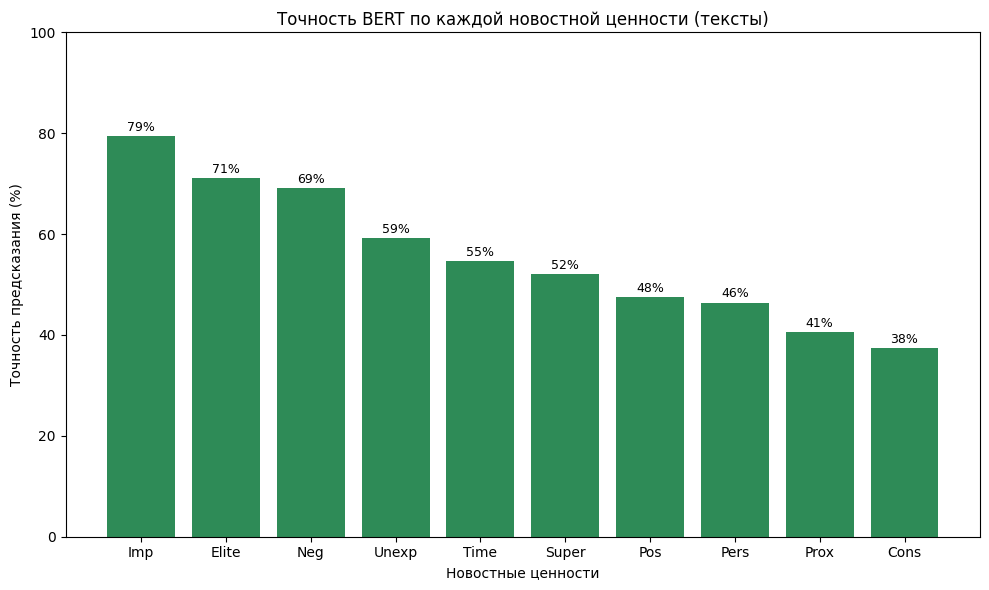

In [56]:
import matplotlib.pyplot as plt

# Список всех тегов
tags = ['Neg', 'Imp', 'Elite', 'Time', 'Super', 'Prox', 'Pos', 'Pers', 'Cons', 'Unexp']

# Считаем для каждого тега, в скольких новостях BERT угадал
tag_accuracy = []

for tag in tags:
    correct = 0
    total = 0
    for idx in range(len(df_withAI)):
        human = str_to_set(df_withAI.loc[idx, 'Текст_руками'])
        bert = str_to_set(df_withAI.loc[idx, 'Текст_BERT'])

        if tag in human or tag in bert:
            total += 1
            if tag in human and tag in bert:
                correct += 1

    if total > 0:
        tag_accuracy.append(correct / total * 100)
    else:
        tag_accuracy.append(0)

# Сортируем по убыванию
sorted_pairs = sorted(zip(tags, tag_accuracy), key=lambda x: x[1], reverse=True)
sorted_tags = [pair[0] for pair in sorted_pairs]
sorted_accuracy = [pair[1] for pair in sorted_pairs]

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(sorted_tags, sorted_accuracy, color='seagreen')
plt.xlabel('Новостные ценности')
plt.ylabel('Точность предсказания (%)')
plt.title('Точность BERT по каждой новостной ценности (тексты)')
plt.ylim(0, 100)
for i, acc in enumerate(sorted_accuracy):
    plt.text(i, acc + 1, f'{acc:.0f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

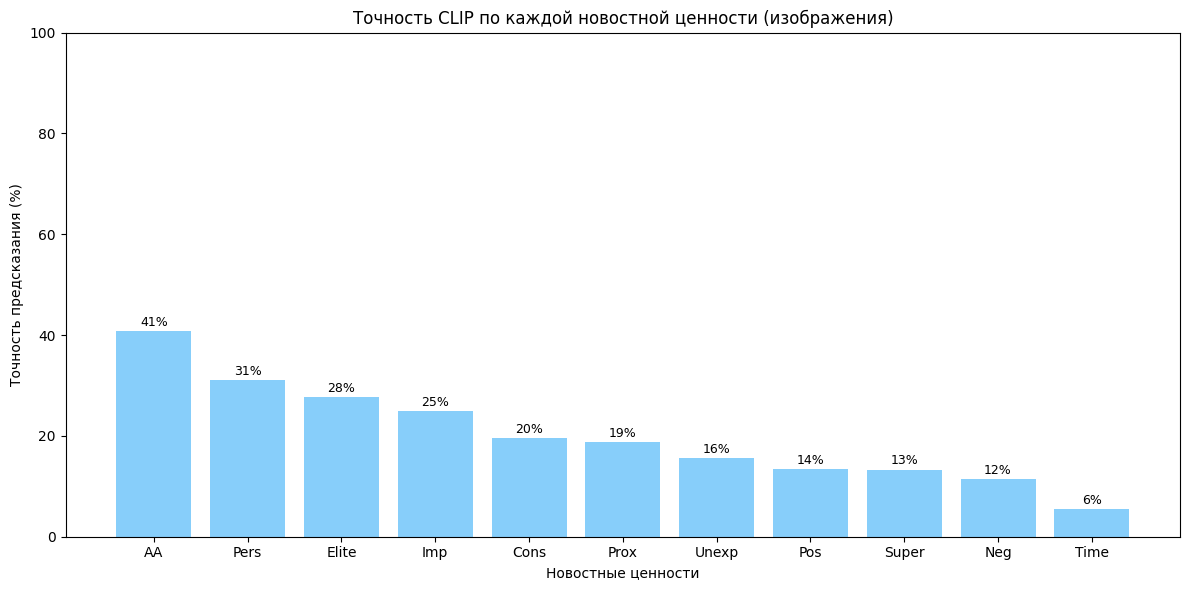

In [57]:
tags_clip = ['AA', 'Neg', 'Pos', 'Elite', 'Super', 'Pers', 'Time', 'Prox', 'Unexp', 'Imp', 'Cons']

def str_to_set(s):
    if pd.isna(s) or s == '':
        return set()
    return set(s.split('\n'))

tag_accuracy_clip = []

for tag in tags_clip:
    correct = 0
    total = 0
    for idx in range(len(df_withAI)):
        human = str_to_set(df_withAI.loc[idx, 'Изображение_руками'])
        clip = str_to_set(df_withAI.loc[idx, 'Изображение_CLIP'])

        if tag in human or tag in clip:
            total += 1
            if tag in human and tag in clip:
                correct += 1

    if total > 0:
        tag_accuracy_clip.append(correct / total * 100)
    else:
        tag_accuracy_clip.append(0)

# Сортируем по убыванию
sorted_pairs = sorted(zip(tags_clip, tag_accuracy_clip), key=lambda x: x[1], reverse=True)
sorted_tags = [pair[0] for pair in sorted_pairs]
sorted_accuracy = [pair[1] for pair in sorted_pairs]

plt.figure(figsize=(12, 6))
plt.bar(sorted_tags, sorted_accuracy, color='lightskyblue')
plt.xlabel('Новостные ценности')
plt.ylabel('Точность предсказания (%)')
plt.title('Точность CLIP по каждой новостной ценности (изображения)')
plt.ylim(0, 100)
for i, acc in enumerate(sorted_accuracy):
    plt.text(i, acc + 1, f'{acc:.0f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

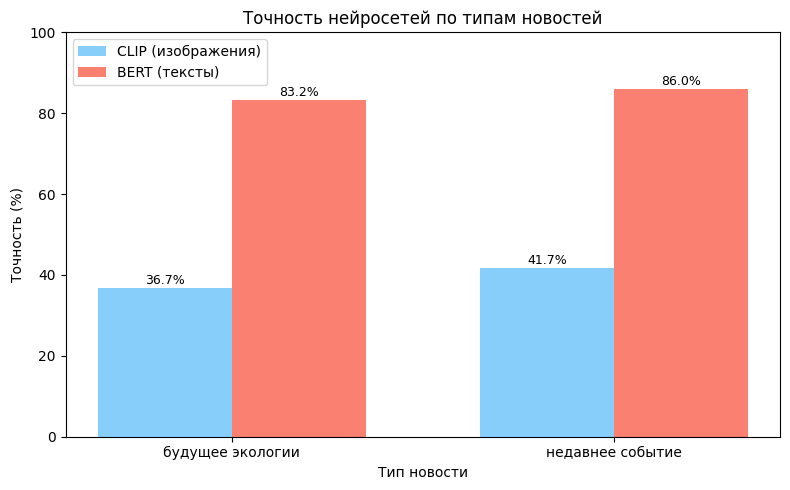

In [59]:
# Получаем уникальные типы новостей
news_types = df_withAI['Тип новости'].unique()

# Функция для преобразования строки с \n в множество
def str_to_set(s):
    if pd.isna(s) or s == '':
        return set()
    return set(s.split('\n'))

# Считаем точность для каждого типа
clip_accuracy_by_type = []
bert_accuracy_by_type = []

for news_type in news_types:
    # Индексы новостей данного типа
    indices = df_withAI[df_withAI['Тип новости'] == news_type].index

    # CLIP точность
    clip_matches = []
    for idx in indices:
        human = str_to_set(df_withAI.loc[idx, 'Изображение_руками'])
        clip = str_to_set(df_withAI.loc[idx, 'Изображение_CLIP'])

        if len(human) > 0:
            match_percent = len(human & clip) / len(human) * 100
        else:
            match_percent = 100 if len(clip) == 0 else 0
        clip_matches.append(match_percent)
    clip_accuracy_by_type.append(np.mean(clip_matches))

    # BERT точность
    bert_matches = []
    for idx in indices:
        human = str_to_set(df_withAI.loc[idx, 'Текст_руками'])
        bert = str_to_set(df_withAI.loc[idx, 'Текст_BERT'])

        if len(human) > 0:
            match_percent = len(human & bert) / len(human) * 100
        else:
            match_percent = 100 if len(bert) == 0 else 0
        bert_matches.append(match_percent)
    bert_accuracy_by_type.append(np.mean(bert_matches))

# Строим график
x = np.arange(len(news_types))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, clip_accuracy_by_type, width, label='CLIP (изображения)', color='lightskyblue')
plt.bar(x + width/2, bert_accuracy_by_type, width, label='BERT (тексты)', color='salmon')

plt.xlabel('Тип новости')
plt.ylabel('Точность (%)')
plt.title('Точность нейросетей по типам новостей')
plt.xticks(x, news_types)
plt.legend()
plt.ylim(0, 100)

for i, (clip_acc, bert_acc) in enumerate(zip(clip_accuracy_by_type, bert_accuracy_by_type)):
    plt.text(i - width/2, clip_acc + 1, f'{clip_acc:.1f}%', ha='center', fontsize=9)
    plt.text(i + width/2, bert_acc + 1, f'{bert_acc:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

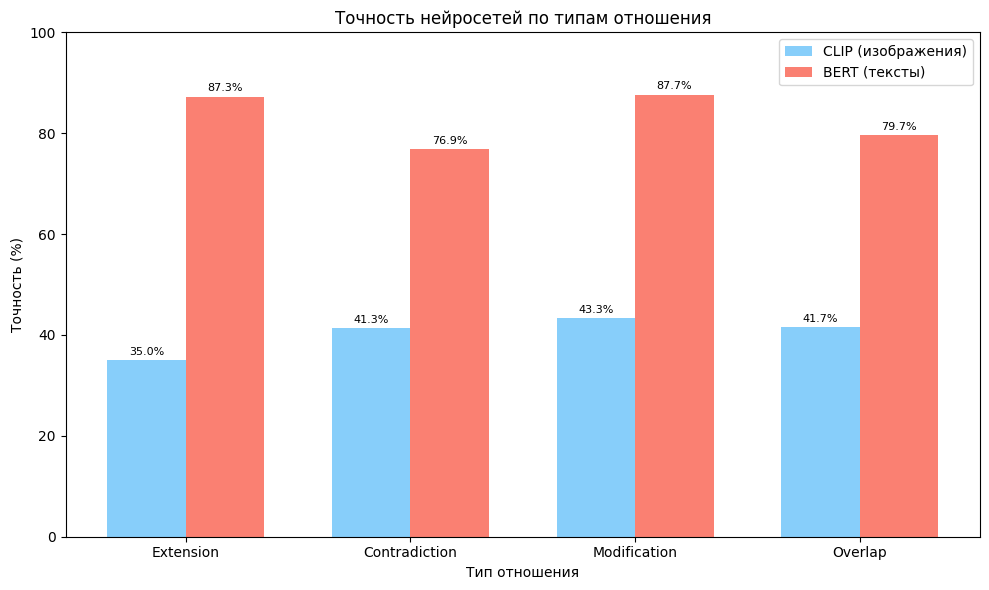

In [47]:
# Получаем уникальные типы отношения
relation_types = df_withAI['Отношение'].unique()

# Функция для преобразования строки с \n в множество
def str_to_set(s):
    if pd.isna(s) or s == '':
        return set()
    return set(s.split('\n'))

# Считаем точность для каждого типа отношения
clip_accuracy_by_relation = []
bert_accuracy_by_relation = []

for rel_type in relation_types:
    # Индексы новостей данного типа отношения
    indices = df_withAI[df_withAI['Отношение'] == rel_type].index

    # CLIP точность
    clip_matches = []
    for idx in indices:
        human = str_to_set(df_withAI.loc[idx, 'Изображение_руками'])
        clip = str_to_set(df_withAI.loc[idx, 'Изображение_CLIP'])

        if len(human) > 0:
            match_percent = len(human & clip) / len(human) * 100
        else:
            match_percent = 100 if len(clip) == 0 else 0
        clip_matches.append(match_percent)
    clip_accuracy_by_relation.append(np.mean(clip_matches))

    # BERT точность
    bert_matches = []
    for idx in indices:
        human = str_to_set(df_withAI.loc[idx, 'Текст_руками'])
        bert = str_to_set(df_withAI.loc[idx, 'Текст_BERT'])

        if len(human) > 0:
            match_percent = len(human & bert) / len(human) * 100
        else:
            match_percent = 100 if len(bert) == 0 else 0
        bert_matches.append(match_percent)
    bert_accuracy_by_relation.append(np.mean(bert_matches))

# Строим график
x = np.arange(len(relation_types))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, clip_accuracy_by_relation, width, label='CLIP (изображения)', color='lightskyblue')
plt.bar(x + width/2, bert_accuracy_by_relation, width, label='BERT (тексты)', color='salmon')

plt.xlabel('Тип отношения')
plt.ylabel('Точность (%)')
plt.title('Точность нейросетей по типам отношения')
plt.xticks(x, relation_types)
plt.legend()
plt.ylim(0, 100)

for i, (clip_acc, bert_acc) in enumerate(zip(clip_accuracy_by_relation, bert_accuracy_by_relation)):
    plt.text(i - width/2, clip_acc + 1, f'{clip_acc:.1f}%', ha='center', fontsize=8)
    plt.text(i + width/2, bert_acc + 1, f'{bert_acc:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [49]:
from scipy import stats

# Функция для преобразования строки с \n в множество
def str_to_set(s):
    if pd.isna(s) or s == '':
        return set()
    return set(s.split('\n'))

# ========== 1. АНАЛИЗ ПО ТИПАМ ОТНОШЕНИЯ ==========
print("=" * 50)
print("АНАЛИЗ ЗНАЧИМОСТИ ОТЛИЧИЙ МЕЖДУ ТИПАМИ ОТНОШЕНИЯ")
print("=" * 50)

relation_types = df_withAI['Отношение'].unique()
relation_data_clip = {}
relation_data_bert = {}

for rel_type in relation_types:
    indices = df_withAI[df_withAI['Отношение'] == rel_type].index

    # CLIP точность для каждого типа
    clip_matches = []
    for idx in indices:
        human = str_to_set(df_withAI.loc[idx, 'Изображение_руками'])
        clip = str_to_set(df_withAI.loc[idx, 'Изображение_CLIP'])
        if len(human) > 0:
            match_percent = len(human & clip) / len(human) * 100
        else:
            match_percent = 100 if len(clip) == 0 else 0
        clip_matches.append(match_percent)
    relation_data_clip[rel_type] = clip_matches

    # BERT точность для каждого типа
    bert_matches = []
    for idx in indices:
        human = str_to_set(df_withAI.loc[idx, 'Текст_руками'])
        bert = str_to_set(df_withAI.loc[idx, 'Текст_BERT'])
        if len(human) > 0:
            match_percent = len(human & bert) / len(human) * 100
        else:
            match_percent = 100 if len(bert) == 0 else 0
        bert_matches.append(match_percent)
    relation_data_bert[rel_type] = bert_matches

# ANOVA для CLIP по типам отношения
clip_values = [relation_data_clip[rt] for rt in relation_types]
f_stat_clip, p_val_clip = stats.f_oneway(*clip_values)
print(f"\nCLIP: F-статистика = {f_stat_clip:.3f}, p-значение = {p_val_clip:.4f}")
print(f"Разница статистически значима: {'Да' if p_val_clip < 0.05 else 'Нет'}")

# ANOVA для BERT по типам отношения
bert_values = [relation_data_bert[rt] for rt in relation_types]
f_stat_bert, p_val_bert = stats.f_oneway(*bert_values)
print(f"BERT: F-статистика = {f_stat_bert:.3f}, p-значение = {p_val_bert:.4f}")
print(f"Разница статистически значима: {'Да' if p_val_bert < 0.05 else 'Нет'}")

# ========== 2. АНАЛИЗ ПО ТИПАМ НОВОСТИ ==========
print("\n" + "=" * 50)
print("АНАЛИЗ ЗНАЧИМОСТИ ОТЛИЧИЙ МЕЖДУ ТИПАМИ НОВОСТИ")
print("=" * 50)

news_types = df_withAI['Тип новости'].unique()
news_data_clip = {}
news_data_bert = {}

for news_type in news_types:
    indices = df_withAI[df_withAI['Тип новости'] == news_type].index

    # CLIP точность
    clip_matches = []
    for idx in indices:
        human = str_to_set(df_withAI.loc[idx, 'Изображение_руками'])
        clip = str_to_set(df_withAI.loc[idx, 'Изображение_CLIP'])
        if len(human) > 0:
            match_percent = len(human & clip) / len(human) * 100
        else:
            match_percent = 100 if len(clip) == 0 else 0
        clip_matches.append(match_percent)
    news_data_clip[news_type] = clip_matches

    # BERT точность
    bert_matches = []
    for idx in indices:
        human = str_to_set(df_withAI.loc[idx, 'Текст_руками'])
        bert = str_to_set(df_withAI.loc[idx, 'Текст_BERT'])
        if len(human) > 0:
            match_percent = len(human & bert) / len(human) * 100
        else:
            match_percent = 100 if len(bert) == 0 else 0
        bert_matches.append(match_percent)
    news_data_bert[news_type] = bert_matches

# T-тест для CLIP (только 2 типа)
clip_values_news = [news_data_clip[nt] for nt in news_types]
t_stat_clip, p_val_clip = stats.ttest_ind(*clip_values_news)
print(f"\nCLIP: t-статистика = {t_stat_clip:.3f}, p-значение = {p_val_clip:.4f}")
print(f"Разница статистически значима: {'Да' if p_val_clip < 0.05 else 'Нет'}")

# T-тест для BERT
bert_values_news = [news_data_bert[nt] for nt in news_types]
t_stat_bert, p_val_bert = stats.ttest_ind(*bert_values_news)
print(f"BERT: t-статистика = {t_stat_bert:.3f}, p-значение = {p_val_bert:.4f}")
print(f"Разница статистически значима: {'Да' if p_val_bert < 0.05 else 'Нет'}")

АНАЛИЗ ЗНАЧИМОСТИ ОТЛИЧИЙ МЕЖДУ ТИПАМИ ОТНОШЕНИЯ

CLIP: F-статистика = 0.321, p-значение = 0.8101
Разница статистически значима: Нет
BERT: F-статистика = 1.549, p-значение = 0.2069
Разница статистически значима: Нет

АНАЛИЗ ЗНАЧИМОСТИ ОТЛИЧИЙ МЕЖДУ ТИПАМИ НОВОСТИ

CLIP: t-статистика = -0.672, p-значение = 0.5034
Разница статистически значима: Нет
BERT: t-статистика = -0.694, p-значение = 0.4890
Разница статистически значима: Нет


ОШИБКИ CLIP (ИЗОБРАЖЕНИЯ)

False Positive (модель предсказала там, где нет):
  AA: 17 раз(а)
  Neg: 5 раз(а)
  Imp: 9 раз(а)
  Elite: 3 раз(а)
  Time: 14 раз(а)
  Super: 13 раз(а)
  Prox: 1 раз(а)
  Pos: 23 раз(а)
  Pers: 9 раз(а)
  Cons: 29 раз(а)
  Unexp: 46 раз(а)

False Negative (модель пропустила там, где есть):
  AA: 15 раз(а)
  Neg: 18 раз(а)
  Imp: 6 раз(а)
  Elite: 10 раз(а)
  Time: 3 раз(а)
  Super: 13 раз(а)
  Prox: 12 раз(а)
  Pos: 9 раз(а)
  Pers: 11 раз(а)
  Cons: 16 раз(а)
  Unexp: 3 раз(а)


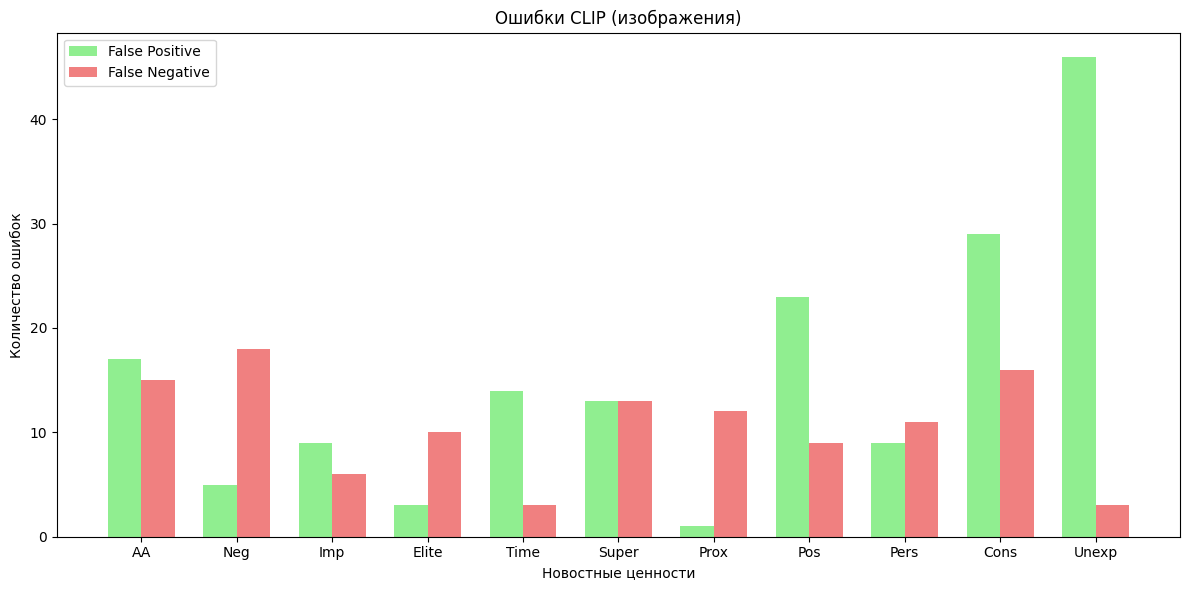

In [55]:
# Список тегов для CLIP
tags_clip = ['AA', 'Neg', 'Imp', 'Elite', 'Time', 'Super', 'Prox', 'Pos', 'Pers', 'Cons', 'Unexp']

# Считаем ошибки для CLIP
print("=" * 60)
print("ОШИБКИ CLIP (ИЗОБРАЖЕНИЯ)")
print("=" * 60)

clip_fp = {tag: 0 for tag in tags_clip}
clip_fn = {tag: 0 for tag in tags_clip}

for idx in range(len(df_withAI)):
    human = str_to_set(df_withAI.loc[idx, 'Изображение_руками'])
    clip = str_to_set(df_withAI.loc[idx, 'Изображение_CLIP'])

    for tag in tags_clip:
        if tag in clip and tag not in human:
            clip_fp[tag] += 1
        if tag in human and tag not in clip:
            clip_fn[tag] += 1

print("\nFalse Positive (модель предсказала там, где нет):")
for tag in tags_clip:
    if clip_fp[tag] > 0:
        print(f"  {tag}: {clip_fp[tag]} раз(а)")

print("\nFalse Negative (модель пропустила там, где есть):")
for tag in tags_clip:
    if clip_fn[tag] > 0:
        print(f"  {tag}: {clip_fn[tag]} раз(а)")

# Визуализация ошибок CLIP
plt.figure(figsize=(12, 6))
x = np.arange(len(tags_clip))
width = 0.35

plt.bar(x - width/2, [clip_fp[tag] for tag in tags_clip], width, label='False Positive', color='lightgreen')
plt.bar(x + width/2, [clip_fn[tag] for tag in tags_clip], width, label='False Negative', color='lightcoral')
plt.xlabel('Новостные ценности')
plt.ylabel('Количество ошибок')
plt.title('Ошибки CLIP (изображения)')
plt.xticks(x, tags_clip)
plt.legend()
plt.tight_layout()
plt.show()


ОШИБКИ BERT (ТЕКСТЫ)

False Positive (модель предсказала там, где нет):
  Neg: 18 раз(а)
  Imp: 13 раз(а)
  Elite: 9 раз(а)
  Time: 19 раз(а)
  Super: 23 раз(а)
  Prox: 16 раз(а)
  Pos: 28 раз(а)
  Pers: 15 раз(а)
  Cons: 4 раз(а)
  Unexp: 9 раз(а)

False Negative (модель пропустила там, где есть):
  Neg: 3 раз(а)
  Imp: 3 раз(а)
  Elite: 8 раз(а)
  Time: 15 раз(а)
  Prox: 3 раз(а)
  Pos: 4 раз(а)
  Cons: 1 раз(а)
  Unexp: 2 раз(а)


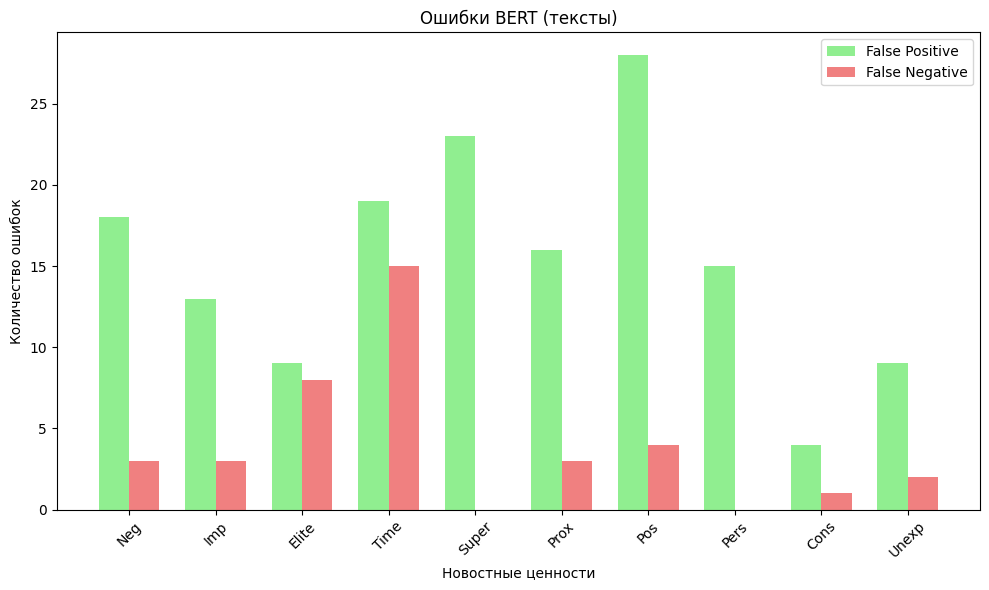

In [54]:
# Список тегов без AA для BERT
tags_bert = ['Neg', 'Imp', 'Elite', 'Time', 'Super', 'Prox', 'Pos', 'Pers', 'Cons', 'Unexp']

# Считаем ошибки для BERT
print("\n" + "=" * 60)
print("ОШИБКИ BERT (ТЕКСТЫ)")
print("=" * 60)

bert_fp = {tag: 0 for tag in tags_bert}
bert_fn = {tag: 0 for tag in tags_bert}

for idx in range(len(df_withAI)):
    human = str_to_set(df_withAI.loc[idx, 'Текст_руками'])
    bert = str_to_set(df_withAI.loc[idx, 'Текст_BERT'])

    for tag in tags_bert:
        if tag in bert and tag not in human:
            bert_fp[tag] += 1
        if tag in human and tag not in bert:
            bert_fn[tag] += 1

print("\nFalse Positive (модель предсказала там, где нет):")
for tag in tags_bert:
    if bert_fp[tag] > 0:
        print(f"  {tag}: {bert_fp[tag]} раз(а)")

print("\nFalse Negative (модель пропустила там, где есть):")
for tag in tags_bert:
    if bert_fn[tag] > 0:
        print(f"  {tag}: {bert_fn[tag]} раз(а)")

# Визуализация ошибок BERT
plt.figure(figsize=(10, 6))
x = np.arange(len(tags_bert))
width = 0.35

plt.bar(x - width/2, [bert_fp[tag] for tag in tags_bert], width, label='False Positive', color='lightgreen')
plt.bar(x + width/2, [bert_fn[tag] for tag in tags_bert], width, label='False Negative', color='lightcoral')
plt.xlabel('Новостные ценности')
plt.ylabel('Количество ошибок')
plt.title('Ошибки BERT (тексты)')
plt.xticks(x, tags_bert, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()